<a href="https://colab.research.google.com/github/springboardmentor1234x-stack/CNN-Music-Instrument-Recognition/blob/anitha/instrunet_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
def load_audio(file_path, sr=22050):

    audio, sample_rate = librosa.load(file_path, sr=sr, mono=True)

    return audio, sample_rate

In [3]:
import os

piano_folder = "/content/IRMAS-TrainingData/pia"

files = os.listdir(piano_folder)

print(files[:5])

['182__[pia][dru][cou_fol]1421__1.wav', '[pia][pop_roc]1282__2.wav', '[pia][jaz_blu]1517__2.wav', '[pia][jaz_blu]1504__1.wav', '[pia][pop_roc]1335__1.wav']


In [4]:
import librosa
file_path = os.path.join(piano_folder, files[0])

audio, sr = load_audio(file_path)

print("Loaded file:", files[0])
print("Sample rate:", sr)
print("Audio length:", len(audio))

Loaded file: 182__[pia][dru][cou_fol]1421__1.wav
Sample rate: 22050
Audio length: 66150


In [5]:
def trim_silence(audio):

    trimmed_audio, _ = librosa.effects.trim(audio)

    return trimmed_audio

In [6]:
audio = trim_silence(audio)

print("Trimmed audio length:", len(audio))

Trimmed audio length: 66150


In [7]:
def normalize_audio(audio):

    audio = audio / np.max(np.abs(audio))

    return audio
    audio = normalize_audio(audio)


In [8]:
def generate_mel_spectrogram(audio, sr):

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    return mel_spec_db


In [9]:
import numpy as np
mel_spec = generate_mel_spectrogram(audio, sr)


In [25]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def process_and_visualize(file_path):

    audio, sr = librosa.load(file_path, sr=22050, mono=True)

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(6,4))
    librosa.display.specshow(mel_spec_db, sr=sr)
    plt.title("Mel Spectrogram")
    plt.axis("off")
    plt.show()

Instrument: cel
File: 008__[cel][nod][cla]0058__1.wav


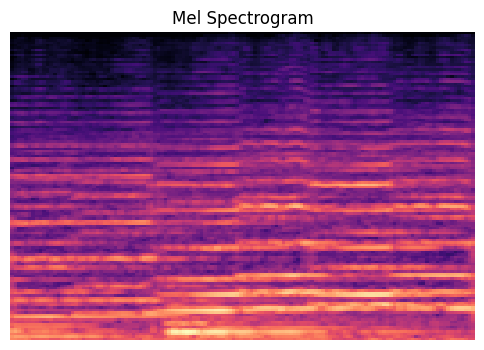

Instrument: cla
File: 004__[cla][nod][cla]0242__1.wav


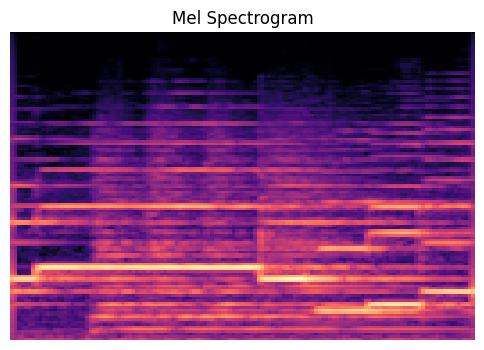

Instrument: flu
File: 008__[flu][nod][cla]0393__1.wav


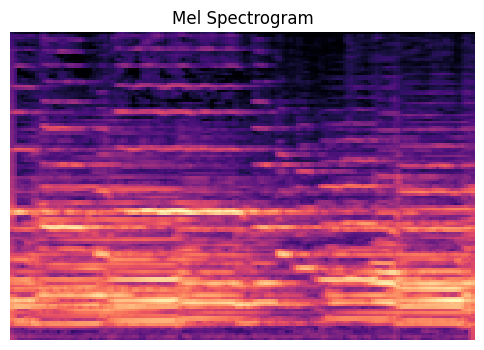

Instrument: gac
File: 014__[gac][nod][cou_fol]0770__1.wav


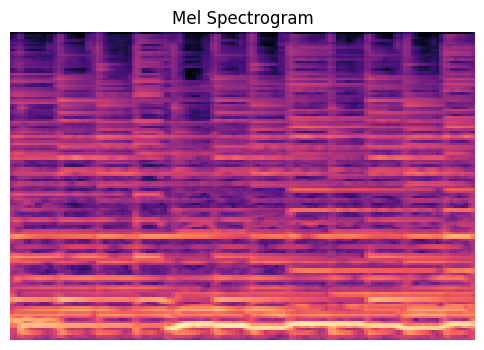

Instrument: gel
File: 001__[gel][dru][pop_roc]0829__1.wav


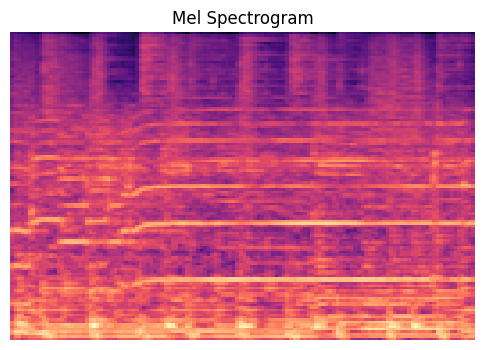

Instrument: org
File: 001__[org][dru][jaz_blu]1123__1.wav


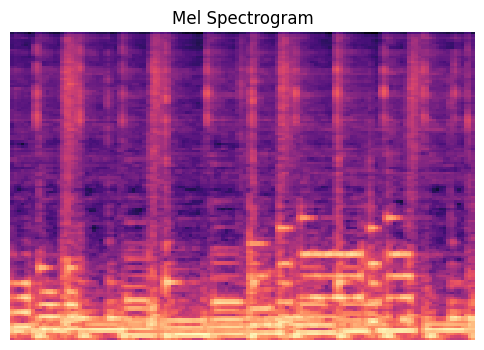

Instrument: pia
File: 001__[pia][nod][cla]1389__1.wav


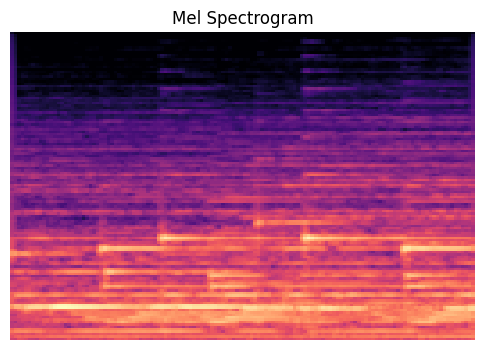

Instrument: sax
File: 006__[sax][nod][cla]1686__1.wav


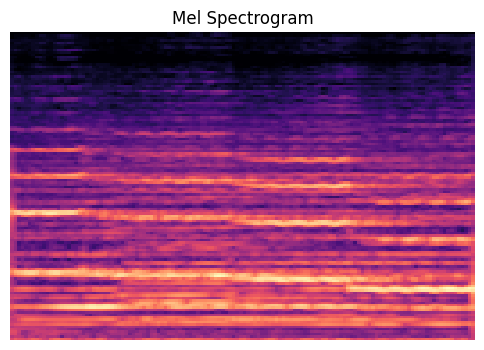

Instrument: tru
File: 001__[tru][nod][jaz_blu]1986__1.wav


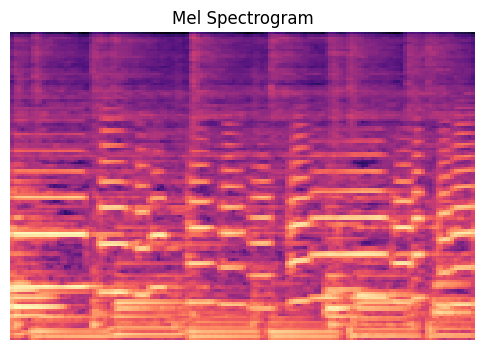

Instrument: vio
File: 001__[vio][nod][cou_fol]2194__1.wav


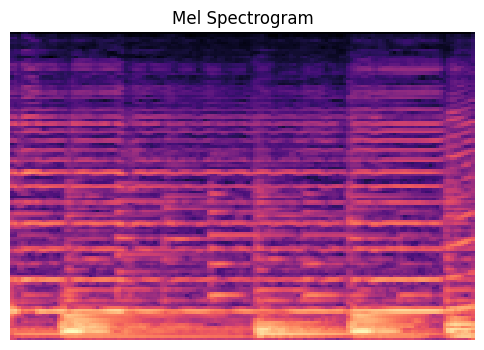

Instrument: voi
File: 001__[voi][dru][pop_roc]2321__1.wav


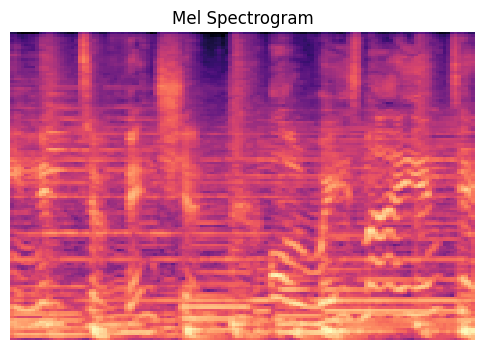

In [26]:
dataset_path = "/content/drive/MyDrive/IRMAS-TrainingData"

for instrument in os.listdir(dataset_path):

    instrument_folder = os.path.join(dataset_path, instrument)

    if os.path.isdir(instrument_folder):

        files = os.listdir(instrument_folder)


        file_path = os.path.join(instrument_folder, files[0])

        print("Instrument:", instrument)
        print("File:", files[0])

        process_and_visualize(file_path)

In [11]:
#1
def save_spectrogram(audio, sr, save_path):

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(3,3))

    librosa.display.specshow(mel_spec_db)

    plt.axis('off')

    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

    plt.close()

In [13]:
#2preprocessing
import matplotlib.pyplot as plt

dataset_path = "/content/IRMAS-TrainingData"

output_path = "/content/spectrogram_dataset"

os.makedirs(output_path, exist_ok=True)

for instrument in os.listdir(dataset_path):

    instrument_folder = os.path.join(dataset_path, instrument)

    if os.path.isdir(instrument_folder):

        save_folder = os.path.join(output_path, instrument)

        os.makedirs(save_folder, exist_ok=True)

        files = os.listdir(instrument_folder)

        print("Processing instrument:", instrument)

        for file in files:

            file_path = os.path.join(instrument_folder, file)

            audio, sr = librosa.load(file_path, sr=22050, mono=True)

            audio, _ = librosa.effects.trim(audio)

            audio = audio / np.max(np.abs(audio))

            save_path = os.path.join(save_folder, file.replace(".wav", ".png"))


            save_spectrogram(audio, sr, save_path)

print("All instruments processed")

Processing instrument: org
Processing instrument: gac
Processing instrument: pia
Processing instrument: cla
Processing instrument: voi
Processing instrument: cel
Processing instrument: tru
Processing instrument: flu
Processing instrument: vio
Processing instrument: gel
Processing instrument: sax
All instruments processed


In [5]:
#train_data
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/drive/MyDrive/spectrogram_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5367 images belonging to 11 classes.
Found 1338 images belonging to 11 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers

In [6]:
model = tf.keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(11, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,059 (12.61 MB)

 Trainable params: 3,306,059 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
#train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.1596 - loss: 0.3147 - val_accuracy: 0.2960 - val_loss: 0.2595
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.3384 - loss: 0.2580 - val_accuracy: 0.4081 - val_loss: 0.2323
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.4653 - loss: 0.2252 - val_accuracy: 0.4970 - val_loss: 0.2194
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.5504 - loss: 0.1994 - val_accuracy: 0.5164 - val_loss: 0.2138
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.6304 - loss: 0.1686 - val_accuracy: 0.5433 - val_loss: 0.2047
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.7116 - loss: 0.1373 - val_accuracy: 0.5097 - val_loss: 0.2343
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.7931 - loss: 0.1050 - val_accuracy: 0.5381 - val_loss: 0.2243
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8743 - loss: 0.0755 - val_accu

In [9]:
predictions = model.predict(val_data)

42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 430ms/step


In [10]:
threshold = 0.5
predicted_labels = (predictions > threshold).astype(int)

In [16]:
true_labels = val_data.labels



In [19]:
import numpy as np
predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)

true_labels = val_data.labels

from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_classes))
#after changing  the output activation from softmax to sigmoid and loss function from categorical_crossentropy to binary_crossentropy,the output shows that f1 score of '10' has the more accuracy rate whoch is '0.17' where '2' has the lowest score with '0.01' which make lowest accuracy and which indicates decreasing in the model performance , as regarding to the dataset IRMAS contains single instrument recordings,thus the softmax gave the more accuracy compared to the sigmoid

42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step
              precision    recall  f1-score   support

           0       0.07      0.04      0.05        77
           1       0.09      0.12      0.10       101
           2       0.01      0.01      0.01        90
           3       0.15      0.13      0.14       127
           4       0.12      0.11      0.11       152
           5       0.08      0.07      0.08       136
           6       0.08      0.06      0.07       144
           7       0.08      0.07      0.08       125
           8       0.05      0.03      0.04       115
           9       0.11      0.21      0.15       116
          10       0.15      0.19      0.17       155

    accuracy                           0.10      1338
   macro avg       0.09      0.10      0.09      1338
weighted avg       0.10      0.10      0.10      1338



In [20]:
for i in range(10):
    print("True:", true_labels[i], "Predicted:", predicted_classes[i])
    #the model misclassified some samples from class 0 as other classes , which indicates that they might have same spectral characteristics in representation of mel_spectrogram, further improvements in the cnn model and increasing 'epochs' can reduce the misclassification

True: 0 Predicted: 10
True: 0 Predicted: 5
True: 0 Predicted: 10
True: 0 Predicted: 4
True: 0 Predicted: 10
True: 0 Predicted: 0
True: 0 Predicted: 10
True: 0 Predicted: 3
True: 0 Predicted: 6
True: 0 Predicted: 8
